# CG3201 Project 2 — Bayesian Classification and Regression for Data Analysis
By Kenneth Wong Cun Wi A0303203A


In [45]:
# Setup and dependencies
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

## Part 1 - Bayesian Modeling for Image Classification with MLE and MAP

### Part 1(a) Data loading and feature construction

We first load the caltech cougar dataset and label (Body = 0; Face = 1), then apply the following preprocessing:

1. Convert all the images to grayscale.
2. Resize them to $64 \times 64$ pixel resolution (bilinear interpolation for smoother resampling / reduced aliasing artifacts).
3. Flatten into a 1D feature vector $x \in \mathbb{R}^{D}$ where $D = 4096$.
Each image becomes a 1D vector $x \in \mathbb{R}^{D}$ with $D = 64 \times 64 = 4096$ features, which are essentially the pixel intensity at each pixel location of the resized image.

We then obtain the data matrix $X \in \mathbb{R}^{N \times D}$ by stacking each image feature vector $x_i$ as a row of $X$.

Perform a stratified train/test split within each class so the training fraction per class does not exceed 75%. We also use a fixed RNG seed when shuffling to avoid bias from file ordering.

Mean image for each class: the "average" picture when many images are lined up and the intensity at each pixel location is averaged. This is the empirical mean of the data for that class (a key statistic for Gaussian Naive Bayes / MLE).

=== Dataset Statistics ===
Total: N=116 | body(0)=47, face(1)=69
Train: N=86 | body(0)=35, face(1)=51
Test : N=30 | body(0)=12,  face(1)=18
Train ratio (body): 0.745
Train ratio (face): 0.739
Feature dimension D: 4096


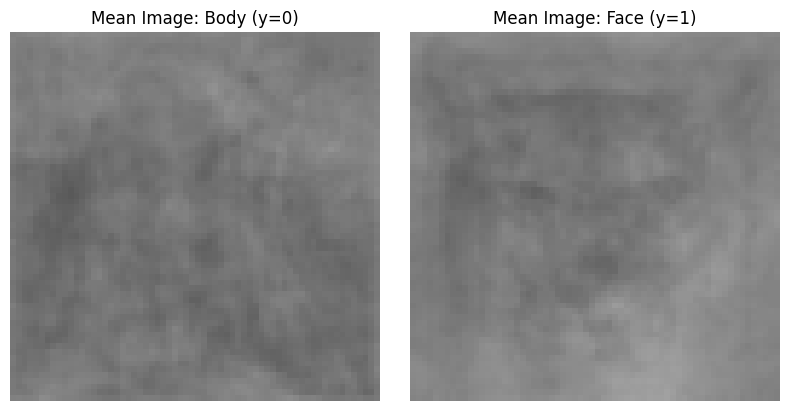

In [ ]:
# --------------- 1. load image paths from caltech_cougar dataset --------------- 
root = Path("caltech_cougar")
if not root.exists():
    root = Path("project2") / "caltech_cougar"

body_root = root / "cougar_body"
face_root = root / "cougar_face"

body_paths = sorted(body_root.glob("*.jpg"))
face_paths = sorted(face_root.glob("*.jpg"))

# --------------- 2. labels: body=0, face=1 --------------- 
paths = body_paths + face_paths
y = np.array([0] * len(body_paths) + [1] * len(face_paths), dtype=np.int64)

# --------------- 3. preprocess images to feature vectors --------------- 
def preprocess_jpg_to_x(
    path: Path,
    size: tuple[int, int] = (64, 64),
    grayscale: bool = True,
) -> np.ndarray:
    """ Grayscale and resize to 64x64 resolution then flatten to a vector of length 4096.
    Return flattened feature vector x from an input JPG path.
    """
    with Image.open(path) as img:
        img = img.convert("L" if grayscale else "RGB") # grayscale or color
        img = img.resize(size, resample=Image.Resampling.BILINEAR) # resize to 64x64 and perform weighted average of nearby pixels
        arr = np.asarray(img, dtype=np.float32)  # turns resized image into a numpy array of shape (64,64) 
    x = arr.reshape(-1)  # 1D vector with shape (4096,) features
    return x

# --------------- 4. Obtain X: the data matrix such that [x_1, x_2, ..., x_N], where each image's feature vector x_i is (4096,) 
# stacked as rows in X  --------------- 
X = np.stack([preprocess_jpg_to_x(p) for p in paths], axis=0)  # shape (N, 4096)
D = X.shape[1] # number of columns (or features, which is 4096)
assert D == 4096, f"Expected D=4096, got D={D}" # just to make sure we have the expected number of features (4096 = 64x64)

# --------------- 5. Stratified train/test split (75:25 per class) --------------- 
SEED = 203 # some fixed seed for reproducibility
TRAIN_RATIO = 0.75

rng = np.random.default_rng(SEED) # for shuffling 

# finds indices (rows) where y == 0 (body class)
idx_body = np.flatnonzero(y == 0) 
idx_face = np.flatnonzero(y == 1) # finds indices (rows) where y == 1 (face class)

 # randomly permutes indices of body/face class
rng.shuffle(idx_body)
rng.shuffle(idx_face)

# floor to prevent > 75%
n_body_train = int(np.floor(TRAIN_RATIO * len(idx_body))) 
n_face_train = int(np.floor(TRAIN_RATIO * len(idx_face)))

# builds final index list for train/test splits by taking the first n_train indices for each class as train, and the rest as test
train_idx = np.concatenate([idx_body[:n_body_train], idx_face[:n_face_train]])
test_idx = np.concatenate([idx_body[n_body_train:], idx_face[n_face_train:]])
rng.shuffle(train_idx)
rng.shuffle(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# --------------- 6. Dataset statistics --------------- 
# Total counts
n_body_total = int((y == 0).sum())
n_face_total = int((y == 1).sum())

# Split counts
n_body_train = int((y_train == 0).sum())
n_face_train = int((y_train == 1).sum())
n_body_test = int((y_test == 0).sum())
n_face_test = int((y_test == 1).sum())

# Per-class training ratios (must be ≤ 0.75)
train_ratio_body = n_body_train / n_body_total
train_ratio_face = n_face_train / n_face_total
assert train_ratio_body <= 0.75 + 1e-12
assert train_ratio_face <= 0.75 + 1e-12

print("=== Dataset Statistics ===")
print(f"Total: N={len(y)} | body(0)={n_body_total}, face(1)={n_face_total}")
print(f"Train: N={len(y_train)} | body(0)={n_body_train}, face(1)={n_face_train}")
print(f"Test : N={len(y_test)} | body(0)={n_body_test},  face(1)={n_face_test}")
print(f"Train ratio (body): {train_ratio_body:.3f}")
print(f"Train ratio (face): {train_ratio_face:.3f}")
print(f"Feature dimension D: {D}")

# --------------- 7. Mean image visualization --------------- 
mean_body = X_train[y_train == 0].mean(axis=0).reshape(64, 64)
mean_face = X_train[y_train == 1].mean(axis=0).reshape(64, 64)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
axes[0].imshow(mean_body, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Mean Image: Body (y=0)")
axes[0].axis("off")

axes[1].imshow(mean_face, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Mean Image: Face (y=1)")
axes[1].axis("off")

plt.show()


## Part 1(b) Bayesian Modeling with Varying Distribution Assumptions (MLE)

### Gaussian Naive Bayes

We classify each image by the posterior distribution $p(y\mid x)$, where $y\in\{0,1\}$ is the class label (0=body, 1=face) and $x\in\mathbb{R}^{D}$ is the feature vector of the image ($D=4096$ flattened $64\times 64$ grayscale pixels).

- By Bayes' rule (posterior $\propto$ prior $\times$ likelihood):
  $$p(y=c \mid x) \propto p(y=c)\,p(x \mid y=c).$$
- For Naive Bayes, we assume pixel features are conditionally independent given the class:
  $$p(x \mid y=c) = \prod_{d=1}^{D} p(x_d \mid y=c).$$
- Using the univariate Gaussian pdf, we model each 1D feature likelihood as:
  $$p(x_d \mid y=c)=\mathcal{N}(x_d\mid \mu_{c,d},\sigma^2_{c,d}).$$

Putting these together gives the Gaussian NB likelihood:
$$p(x \mid y=c) = \prod_{d=1}^{D} \mathcal{N}(x_d \mid \mu_{c,d},\,\sigma^2_{c,d}).$$

For prediction we only need the class $c$ that maximizes the posterior. We compute it in **log-space** (since product becomes sum):
$$\hat{y}(x) = \mathrm{argmax}_{c} \Big[\log p(y=c) + \sum_{d=1}^{D} \log \mathcal{N}(x_d \mid \mu_{c,d},\sigma^2_{c,d})\Big].$$

The prediction formula needs the parameters $\mu_{c,d}$ and $\sigma^2_{c,d}$ (and the prior $p(y=c)$). We do not know these parameters, so we estimate them from the training set using MLE.

### MLE for the Gaussian parameters (pdf → NLL → optimal parameter)

From the univariate Gaussian pdf:
$$p(x\mid \mu,\sigma^2)=\mathcal{N}(x\mid \mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big).$$

Then the likelihood is the product of pdf values:
$$L(\mu,\sigma^2)=\prod_{i=1}^{n} p(x_i\mid \mu,\sigma^2).$$

The negative log-likelihood (NLL) is
$$\mathrm{NLL}(\mu,\sigma^2)=-\log L(\mu,\sigma^2)=-\sum_{i=1}^{n}\log p(x_i\mid\mu,\sigma^2).$$
Substituting the Gaussian pdf into the NLL and simplifying gives
$$\mathrm{NLL}(\mu,\sigma^2)=\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2+\frac{n}{2}\log(2\pi\sigma^2).$$

MLE chooses the parameters that minimize the NLL:
$$\hat{\theta}_{\mathrm{mle}}=(\hat{\mu},\hat{\sigma}^2)=\mathrm{argmin}_{\mu,\sigma^2}\;\mathrm{NLL}(\mu,\sigma^2).$$

To minimise the NLL and obtain the optimal parameters, take the partial derivatives and setting to zero:
$$\frac{\partial}{\partial \mu}\mathrm{NLL}(\mu,\sigma^2) = -\frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)=0.$$
$$\frac{\partial}{\partial \sigma^2}\mathrm{NLL}(\mu,\sigma^2) = -\frac{1}{2\sigma^4}\sum_{i=1}^{n}(x_i-\mu)^2+\frac{n}{2\sigma^2}=0.$$

Solving these gives the MLE optimal parameters:
$$\hat{\mu}=\frac{1}{n}\sum_{i=1}^{n}x_i,\qquad
\hat{\sigma}^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{\mu})^2.$$
which are simply the empirical mean and variance of the observed data.

### Implementation of Gaussian Naive Bayes Classifier
Hence, to obtain the Gaussian Naive Bayes classifier, we do the following steps for each class:

1) Collect the class-specific data
- Let $X_c\in\mathbb{R}^{N_c\times D}$ be the sub-matrix of rows with $y=c$.

2) Estimate the class prior
$$\hat{\pi}_c = \hat{p}(y=c) = \frac{N_c}{N}.$$

3) Estimate the mean vector
- For each pixel feature $d$, the MLE mean is simply the empirical average of that column within the class:
  $$\hat{\mu}_{c,d}=\frac{1}{N_c}\sum_{i:y_i=c} x^{(i)}_d.$$
- Stacking all $d=1,\dots,D$ gives the mean vector $\hat{\mu}_c\in\mathbb{R}^{D}$.

4) Estimate the variance vector
- For each pixel feature $d$, the MLE variance is simply the empirical variance:
  $$\hat{\sigma}^2_{c,d}=\frac{1}{N_c}\sum_{i:y_i=c}(x^{(i)}_d-\hat{\mu}_{c,d})^2.$$
- Stacking all $d$ gives the variance vector $\hat{\sigma}^2_c\in\mathbb{R}^{D}$.

5) Predict in log-space
- For a test image $x$, we compute
  $$s_c(x)=\log \hat{\pi}_c + \sum_{d=1}^{D}\log \mathcal{N}(x_d\mid \hat{\mu}_{c,d},\hat{\sigma}^2_{c,d}),\qquad \hat{y}(x)=\mathrm{argmax}_{c} s_c(x).$$

In [71]:
# MLE for Gaussian Naive Bayes
#
# For each class c, estimate:
# mu_c[d] = average of feature d among training samples with y=c
# sigma2_c[d] = average squared deviation of feature d among training samples with y=c

EPS = 1e-6  # small value to avoid divide-by-zero when a feature has (near) zero variance

# Split training data by class
X0 = X_train[y_train == 0]  # body
X1 = X_train[y_train == 1]  # face

# π_c = p(y=c): count / N (class priors)
pi0 = X0.shape[0] / X_train.shape[0]
pi1 = X1.shape[0] / X_train.shape[0]

# Mean vectors
mu0 = X0.mean(axis=0)
mu1 = X1.mean(axis=0)

# Variance vectors
sigma2_0 = X0.var(axis=0) + EPS
sigma2_1 = X1.var(axis=0) + EPS

# Predict with log posterior
#
# For each class c:
# log p(y=c | x) = log p(y=c) + sum_d log N(x_d | mu_c[d], sigma2_c[d])

def log_gaussian_nb_score(X_in: np.ndarray, mu: np.ndarray, sigma2: np.ndarray, log_pi: float) -> np.ndarray:
    """Return log p(y=c) + log p(x | y=c) for each row in X_in."""
    # X_in: (N, D)
    # mu, sigma2: (D,)
    # Output: (N,)

    # term1: sum_d log(2πσ^2)
    term1 = np.sum(np.log(2.0 * np.pi * sigma2))

    # term2: sum_d (x - μ)^2 / σ^2, computed per sample
    term2 = np.sum(((X_in - mu) ** 2) / sigma2, axis=1)

    # log-likelihood:
    #   log p(x|y=c) = -0.5 * [term1 + term2]
    return log_pi - 0.5 * (term1 + term2)

log_pi0 = float(np.log(pi0))
log_pi1 = float(np.log(pi1))

# Train set prediction
score0_train = log_gaussian_nb_score(X_train, mu0, sigma2_0, log_pi0)
score1_train = log_gaussian_nb_score(X_train, mu1, sigma2_1, log_pi1)
y_pred_train = (score1_train > score0_train).astype(np.int64)
accuracy_train = float((y_pred_train == y_train).mean())

# Test set prediction
score0 = log_gaussian_nb_score(X_test, mu0, sigma2_0, log_pi0)
score1 = log_gaussian_nb_score(X_test, mu1, sigma2_1, log_pi1)

# Predict the class with higher log posterior where(score1 > score0) => predict 1 else 0
y_pred = (score1 > score0).astype(np.int64)

# Evaluate
#
# accuracy + confusion matrix

accuracy = float((y_pred == y_test).mean())

# Confusion matrix with rows=true, cols=pred
# [[TN, FP],
#  [FN, TP]]
TN = int(((y_test == 0) & (y_pred == 0)).sum())
FP = int(((y_test == 0) & (y_pred == 1)).sum())
FN = int(((y_test == 1) & (y_pred == 0)).sum())
TP = int(((y_test == 1) & (y_pred == 1)).sum())
conf_mat = np.array([[TN, FP], [FN, TP]], dtype=int)

print("=== Gaussian Naive Bayes (MLE) ===")
print("Class mapping: y=0 is body, y=1 is face")
print(f"π0 = p(y=0) = {pi0:.3f} (class prior for body)")
print(f"π1 = p(y=1) = {pi1:.3f} (class prior for face)")
print(f"μ0 shape={mu0.shape}, μ1 shape={mu1.shape}  (mean vectors)")
print(f"σ²0 shape={sigma2_0.shape}, σ²1 shape={sigma2_1.shape}  (variance vectors)")
print("")
print(f"Train accuracy: {accuracy_train:.4f}")
print(f"Test accuracy:  {accuracy:.4f}")
print("Confusion matrix (rows=true y, cols=predicted ŷ):")
print(conf_mat)


=== Gaussian Naive Bayes (MLE) ===
Class mapping: y=0 is body, y=1 is face
π0 = p(y=0) = 0.407 (class prior for body)
π1 = p(y=1) = 0.593 (class prior for face)
μ0 shape=(4096,), μ1 shape=(4096,)  (mean vectors)
σ²0 shape=(4096,), σ²1 shape=(4096,)  (variance vectors)

Train accuracy: 0.6977
Test accuracy:  0.3667
Confusion matrix (rows=true y, cols=predicted ŷ):
[[ 4  8]
 [11  7]]


### Laplace Naive Bayes

Now for Laplace Naive Bayes, we change the model for each 1D feature likelihood with a Laplace (double-sided exponential) distribution:
$$p(x_d \mid y=c)=\mathrm{Laplace}(x_d\mid \mu_{c,d},b_{c,d})=\frac{1}{2b_{c,d}}\exp\Big(-\frac{|x_d-\mu_{c,d}|}{b_{c,d}}\Big).$$

### MLE for the Laplace parameters (pdf → NLL → optimal parameter)

From the univariate Laplace pdf:
$$p(x\mid \mu,b)=\frac{1}{2b}\exp\Big(-\frac{|x-\mu|}{b}\Big),\qquad b>0.$$


Substituting the Laplace pdf into the NLL and simplifying gives
$$\mathrm{NLL}(\mu,b)=-\sum_{i=1}^{n}\log\Big(\frac{1}{2b}\exp\Big(-\frac{|x_i-\mu|}{b}\Big)\Big).$$
$$\mathrm{NLL}(\mu,b)=n\log(2b)+\frac{1}{b}\sum_{i=1}^{n}|x_i-\mu|.$$

Minimizing the NLL yields the MLE parameters:
$$\hat{\mu}=\mathrm{median}(x_1,\dots,x_n),\qquad
\hat{b}=\frac{1}{n}\sum_{i=1}^{n}|x_i-\hat{\mu}|.$$

(For $b$, taking $\partial\,\mathrm{NLL}/\partial b=0$ gives $\hat{b}$; for $\mu$, minimizing $\sum_i |x_i-\mu|$ gives the sample median.)

### Implementation of Laplace Naive Bayes Classifier
Hence, to obtain the Laplace Naive Bayes classifier, we do the following steps for each class:

1) Collect the class-specific data
- Let $X_c\in\mathbb{R}^{N_c\times D}$ be the sub-matrix of rows with $y=c$.

2) Estimate the class prior
$$\hat{\pi}_c=\hat{p}(y=c)=\frac{N_c}{N}.$$

3) Estimate the location vector (median)
- For each pixel feature $d$, the MLE location is the median of that column within the class:
  $$\hat{\mu}_{c,d}=\mathrm{median}\big(\{x^{(i)}_d: y_i=c\}\big).$$
- Stacking all $d=1,\dots,D$ gives the location vector $\hat{\mu}_c\in\mathbb{R}^{D}$.

4) Estimate the scale vector $b$
- For each pixel feature $d$, the MLE scale is the mean absolute deviation from the median:
  $$\hat{b}_{c,d}=\frac{1}{N_c}\sum_{i:y_i=c}|x^{(i)}_d-\hat{\mu}_{c,d}|.$$
- Stacking all $d$ gives the scale vector $\hat{b}_c\in\mathbb{R}^{D}$.

5) Predict in log-space
- For a test image $x$, we compute
  $$s_c(x)=\log \hat{\pi}_c + \sum_{d=1}^{D}\Big[-\log(2\hat{b}_{c,d})-\frac{|x_d-\hat{\mu}_{c,d}|}{\hat{b}_{c,d}}\Big],\qquad \hat{y}(x)=\mathrm{argmax}_{c} s_c(x).$$

In [72]:
# MLE for Laplace Naive Bayes
#
# For each class c, estimate:
# mu_c[d] = median of feature d among training samples with y=c (location)
# b_c[d] = mean absolute deviation from mu_c[d] among training samples with y=c (scale)

EPS = 1e-6  # small value to avoid divide-by-zero when a feature has (near) zero scale

# Split training data by class
X0 = X_train[y_train == 0]  # body
X1 = X_train[y_train == 1]  # face

# π_c = p(y=c): count / N
pi0_lap = X0.shape[0] / X_train.shape[0]
pi1_lap = X1.shape[0] / X_train.shape[0]

# Location vectors (medians)
mu0_lap = np.median(X0, axis=0)
mu1_lap = np.median(X1, axis=0)

# Scale vectors b (mean absolute deviation from the median)
b0 = np.mean(np.abs(X0 - mu0_lap), axis=0) + EPS
b1 = np.mean(np.abs(X1 - mu1_lap), axis=0) + EPS

# Predict with log posterior 
# 
# For each class c:
# log p(y=c | x) = log p(y=c) + sum_d log Laplace(x_d | mu_c[d], b_c[d])

def log_laplace_nb_score(X_in: np.ndarray, mu: np.ndarray, b: np.ndarray, log_pi: float) -> np.ndarray:
    """Return log p(y=c) + log p(x | y=c) for each row in X_in."""
    # X_in: (N, D)
    # mu, b: (D,)
    # Output: (N,)

    # log Laplace(x|mu,b) = -log(2b) - |x-mu|/b
    term1 = np.sum(np.log(2.0 * b)) # sum_d log(2b_d)
    term2 = np.sum(np.abs(X_in - mu) / b, axis=1)   # sum_d |x_d-mu_d|/b_d 
    return log_pi - (term1 + term2)

log_pi0_lap = float(np.log(pi0_lap))
log_pi1_lap = float(np.log(pi1_lap))

# Train set prediction
score0_lap_train = log_laplace_nb_score(X_train, mu0_lap, b0, log_pi0_lap)
score1_lap_train = log_laplace_nb_score(X_train, mu1_lap, b1, log_pi1_lap)
y_pred_lap_train = (score1_lap_train > score0_lap_train).astype(np.int64)
accuracy_lap_train = float((y_pred_lap_train == y_train).mean())

# Test set prediction
score0_lap = log_laplace_nb_score(X_test, mu0_lap, b0, log_pi0_lap)
score1_lap = log_laplace_nb_score(X_test, mu1_lap, b1, log_pi1_lap)

# Predict the class with higher log posterion where (score1_lap > score0_lap) => predict 1 else 0
y_pred_lap = (score1_lap > score0_lap).astype(np.int64)

# Evaluate
#
# accuracy + confusion matrix
accuracy_lap = float((y_pred_lap == y_test).mean())

TN_lap = int(((y_test == 0) & (y_pred_lap == 0)).sum())
FP_lap = int(((y_test == 0) & (y_pred_lap == 1)).sum())
FN_lap = int(((y_test == 1) & (y_pred_lap == 0)).sum())
TP_lap = int(((y_test == 1) & (y_pred_lap == 1)).sum())
conf_mat_lap = np.array([[TN_lap, FP_lap], [FN_lap, TP_lap]], dtype=int)

print("=== Laplace Naive Bayes (MLE) ===")
print("Class mapping: y=0 is body, y=1 is face")
print(f"π0 = p(y=0) = {pi0_lap:.3f} (class prior for body)")
print(f"π1 = p(y=1) = {pi1_lap:.3f} (class prior for face)")
print(f"μ0 shape={mu0_lap.shape}, μ1 shape={mu1_lap.shape}  (median / location vectors)")
print(f"b0 shape={b0.shape}, b1 shape={b1.shape}  (scale vectors)")
print("")
print(f"Train accuracy: {accuracy_lap_train:.4f}")
print(f"Test accuracy:  {accuracy_lap:.4f}")
print("Confusion matrix (rows=true y, cols=predicted ŷ):")
print(conf_mat_lap)


=== Laplace Naive Bayes (MLE) ===
Class mapping: y=0 is body, y=1 is face
π0 = p(y=0) = 0.407 (class prior for body)
π1 = p(y=1) = 0.593 (class prior for face)
μ0 shape=(4096,), μ1 shape=(4096,)  (median / location vectors)
b0 shape=(4096,), b1 shape=(4096,)  (scale vectors)

Train accuracy: 0.6860
Test accuracy:  0.4333
Confusion matrix (rows=true y, cols=predicted ŷ):
[[4 8]
 [9 9]]


### Evaluation of Gaussian and Laplace Naive Bayes Classifiers
From the previous results, we obtained the following performance metrics:

1. When assuming Gaussian Distribution:
- Train accuracy: 0.6977
- **Test accuracy: 0.3667**
- Confusion matrix: $$\begin{bmatrix}4 & 8 \\ 11 & 7\end{bmatrix}$$

2. When assuming Laplace Naive Bayes
- Train accuracy: 0.6860
- **Test accuracy: 0.4333**
- Confusion matrix: $$\begin{bmatrix}4 & 8 \\ 9 & 9\end{bmatrix}$$

On this split, Laplace NB generalizes better because it achieves a higher test accuracy. From the confusion matrices, Laplace reduces the number of false negatives (face predicted as body) from 11 to 9, increasing true positives from 7 to 9.

However, we do keep in mind that the test set is small ($N_{\text{test}}=30$). The difference corresponds to only 2 additional correct predictions, so while the results suggests Laplace is better on this dataset/split, the gap is not huge.

Additionally, we can also plot the score margin for both classes:
$$\Delta(x)=s_1(x)-s_0(x),$$
where $s_c(x)$ is the log-posterior score for class $c$. The decision boundary is at $\Delta(x)=0$:
- True $y=1$ (face): we want $\Delta(x)>0$.
- True $y=0$ (body): we want $\Delta(x)<0$.


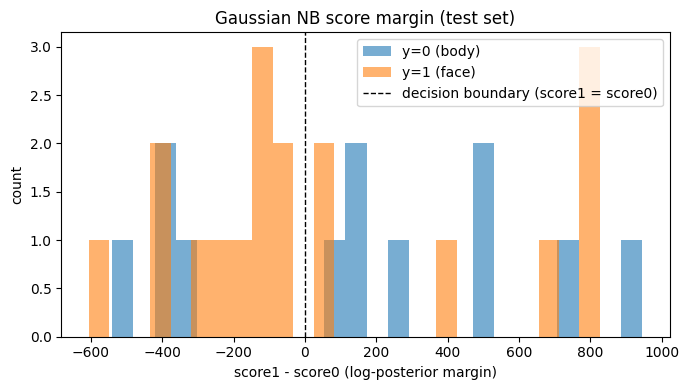

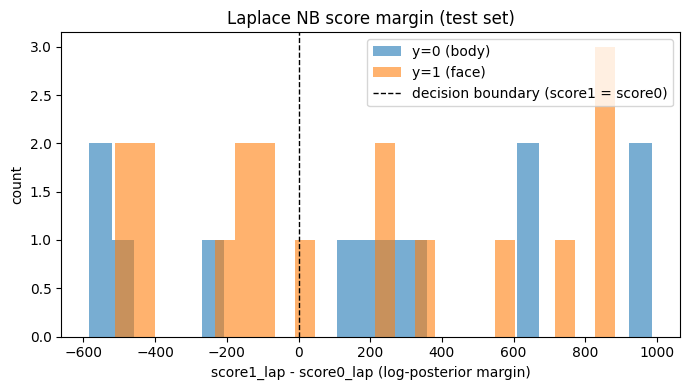

In [73]:
# Plot for Gaussian and Laplace Naive Bayes scores

delta = score1 - score0  # decision boundary is at 0 (predict 1 if delta > 0)

plt.figure(figsize=(7, 4))
plt.hist(delta[y_test == 0], bins=25, alpha=0.6, label="y=0 (body)")
plt.hist(delta[y_test == 1], bins=25, alpha=0.6, label="y=1 (face)")
plt.axvline(0.0, color="k", linestyle="--", linewidth=1.0, label="decision boundary (score1 = score0)")
plt.xlabel("score1 - score0 (log-posterior margin)")
plt.ylabel("count")
plt.title("Gaussian NB score margin (test set)")
plt.legend()
plt.tight_layout()
plt.show()

delta_lap = score1_lap - score0_lap  # decision boundary is at 0 (predict 1 if delta_lap > 0)

plt.figure(figsize=(7, 4))
plt.hist(delta_lap[y_test == 0], bins=25, alpha=0.6, label="y=0 (body)")
plt.hist(delta_lap[y_test == 1], bins=25, alpha=0.6, label="y=1 (face)")
plt.axvline(0.0, color="k", linestyle="--", linewidth=1.0, label="decision boundary (score1 = score0)")
plt.xlabel("score1_lap - score0_lap (log-posterior margin)")
plt.ylabel("count")
plt.title("Laplace NB score margin (test set)")
plt.legend()
plt.tight_layout()
plt.show()

Overlap near $0$ indicates small margins (ambiguous predictions). Misclassifications correspond to samples that fall on the wrong side of $0$.

On a given test set, higher accuracy typically corresponds to less overlap around the decision boundary (i.e., more samples lie on the correct side of $0$).

The confusion matrices connect directly to these plots:
- For the Gaussian plot, there are 11 false negatives, meaning 11 true face images fall on the wrong side ($\Delta(x)<0$).
- For the Laplace plot, there are 9 false negatives, so fewer true face images fall on the wrong side.
- Both models have 8 false positives (body predicted as face), so they make a similar number of body mistakes ($\Delta(x)>0$ for true $y=0$).

### Why Laplace can be better for this dataset (at least conceptually)
Laplace can be a better assumption when the feature noise is heavy-tailed or contains outliers.

- Compared to Gaussian, Laplace has heavier tails (probability of values far from mean drops off more slowly), so it does not over-penalize a few extreme pixel deviations caused by illumination changes, background clutter, or slight misalignment/cropping.
- Its MLE location uses the **median** (instead of the mean), which is more robust when a small fraction of samples have unusually large/small pixel intensities.
- In our high-dimensional setting ($D=4096$) with the Naive Bayes independence assumption, a handful of outlier pixels can disproportionately affect the summed log-likelihood; the Laplace absolute-deviation term is less sensitive than the Gaussian squared-deviation term.

Ultimately, which distribution generalizes better is still an empirical question answered by held-out performance; here, Laplace achieves the higher test accuracy on this split.

### Why are both test accuracies still low? (Performance of functions fitted with ERM)
When fitting the generative model, we estimate parameters using MLE, i.e., by minimizing the negative log-likelihood (NLL). This is a specific case of ERM with the NLL, and the resulting performance can be limited by:
- **Approximation error** $\epsilon_{\mathrm{app}}(\mathcal{H})$ (model mismatch), and
- **Estimation / generalization error** $\epsilon_{\mathrm{est}}(\mathcal{H},N)$ (finite-data effect), which often shows up as a noticeable train–test performance gap.

1) Approximation error (model mismatch)
- Naive Bayes assumes pixels are conditionally independent given the class. Real images have strong spatial correlations (neighbouring pixels move together), so this assumption is violated.
- Each pixel is also modelled by a simple unimodal distribution (Gaussian or Laplace). In practice, pixel values within a class can be multi-modal due to pose/lighting/background changes.

2) Estimation error/generalisation gap (finite data)
- We estimate thousands of parameters per class (one set per pixel feature), but the number of training images is limited. This makes the MLE parameter estimates noisy. (In Part 1(c), using MAP (a prior over parameters) can act like regularization and reduce this estimation error.)

**On this split, the train–test accuracy gap is large (Gaussian: $0.6977-0.3667=0.331$ and Laplace: $0.6860-0.4333=0.2527$).**

3) Outliers / heavy-tailed variations (why Laplace can help)
- Gaussian likelihood penalizes large deviations roughly like $(x-\mu)^2$, while Laplace penalizes like $\left|x-\mu\right|$. This means a few unusual pixels (due to background clutter, misalignment, or illumination) can dominate the Gaussian score more strongly.
- Laplace is therefore more robust to such outlier pixels, which is consistent with its better test performance here.

4) Small test set / evaluation variance
- With only 30 test images, the accuracy can change noticeably if just a few images flip from correct to incorrect.


## Part 1(c) Maximum A Posteriori (MAP) with Unique Prior Analysis
In Part 1(b), we estimated the Gaussian NB parameters purely from data using MLE and we see that the test accuracies are rather low. Now, we incorporate prior knowledge about the Gaussian mean using a Normal prior, and compute a MAP estimate.

Let $S=(s_1,\dots,s_m)$ be the sequence of digits in my student ID. Since digits lie in $[0,9]$ while pixel intensities lie in $[0,255]$, we linearly rescale digits into pixel-intensity units via
$$\tilde{s}_k = \frac{s_k}{9}\cdot 255.$$

The prior mean is constant over pixels, and is the average digit value scaled into $[0,255]$:
$$\mu_{0,i}=\frac{1}{m}\sum_{k=1}^{m}\tilde{s}_k=\frac{\bar{s}}{9}\cdot 255\qquad \text{for all } i,$$
where $\bar{s}=\frac{1}{m}\sum_{k=1}^{m}s_k$.

For prior variance, we first define the digit variance
$$\mathrm{Var}(S)=\frac{1}{m}\sum_{k=1}^{m}(s_k-\bar{s})^2.$$
And as given in the project, the prior variance is a vector $\sigma_0^2\in\mathbb{R}^{D}$ with
$$\sigma^2_{0,i}=\mathrm{Var}(S)\left(1+\frac{i\bmod \mathrm{MaxDigit}}{10}\right),$$
where $\mathrm{MaxDigit}=\max(S)$.

### MAP estimate and uncertainty vs. sample size
For a fixed class and pixel feature, with $n$ samples and empirical mean $\bar{x}$, the posterior over $\mu$ is Normal. The MAP estimate equals the posterior mean:
$$\hat{\mu}_{\mathrm{MAP}}=\frac{\sigma^2\mu_0+n\sigma_0^2\bar{x}}{\sigma^2+n\sigma_0^2}.$$

The posterior variance
  $$\mathrm{Var}(\mu_{c,i}\mid X_c)=\sigma^2_{\mathrm{post},c,i}=\frac{\sigma^2_{c,i}\sigma^2_{0,i}}{\sigma^2_{c,i}+n_c\sigma^2_{0,i}}=\frac{1}{\frac{1}{\sigma^2_{0,i}}+\frac{n_c}{\sigma^2_{c,i}}}$$
  measures how **certain** we are about the parameter $\mu_{c,i}$ after seeing data. As $n_c$ increases, $\sigma^2_{\mathrm{post},c,i}$ decreases, meaning the posterior concentrates and the model becomes more certain about the mean parameter.

*(this is different from $\sigma^2_{c,i}$, which is the variance of the data likelihood; $\sigma^2_{\mathrm{post},c,i}$ is uncertainty about the parameter.)*

### MAP (decision theory vs parameter estimation)
Under **zero-one loss**, the action that minimizes posterior expected loss is to choose the **most probable label** (MAP label):
$$\hat{y}(x)=\arg\max_{c\in\{0,1\}} p(y=c\mid x).$$

Instead of using MLE means, we use MAP-estimated means (a regularized estimate of parameters) before computing $p(y\mid x)$.

Equivalently, taking negative logs shows MAP estimation can be written as minimizing a regularized ERM objective:
$$\hat{\mu}^{\mathrm{MAP}}=\arg\min_{\mu}\;\Big[\underbrace{-\sum_{t=1}^{n}\log p(x^{(t)}\mid\mu)}_{\text{data fit (NLL)}}+\underbrace{-\log p(\mu)}_{\text{prior penalty}}\Big].$$
For a Gaussian prior, the prior penalty reduces estimation error when training data is limited.


In [75]:
# Part 1(c): MAP Gaussian Naive Bayes with prior knowledge

# 1. Build prior knowledge using student ID
STUDENT_ID = "A0303203A"
S = np.array([int(ch) for ch in STUDENT_ID if ch.isdigit()], dtype=np.float32)
scale = 255.0 / 9.0  # map digit range [0,9] to pixel-intensity range [0,255]
S_scaled = S * scale

mean_S = float(S.mean())
var_S_digits = float(S.var())

# Prior mean for all pixels: average value of S scaled to pixel intensity range
mu0_prior = float(mean_S * scale)

max_digit = int(S.max())
if max_digit <= 0:
    max_digit = 1

# Prior variance vector sigma0^2: use formula given in project
# sigma0_i^2 = Var(S) * (1 + (i mod MaxDigit)/10)
idx = np.arange(1, D + 1, dtype=np.int64)
sigma0_2 = var_S_digits * (1.0 + (idx % max_digit) / 10.0)

# 2.MLE variance (taken from Part 1(b))
EPS = 1e-6

X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

n0 = int(X0.shape[0])
n1 = int(X1.shape[0])

pi0 = n0 / X_train.shape[0]
pi1 = n1 / X_train.shape[0]
log_pi0 = float(np.log(pi0))
log_pi1 = float(np.log(pi1))

mu0_mle = X0.mean(axis=0)
mu1_mle = X1.mean(axis=0)
sigma2_0 = X0.var(axis=0) + EPS
sigma2_1 = X1.var(axis=0) + EPS

# 3. MAP mean and posterior variance for mu
# Class-specific sample means
xbar0 = mu0_mle
xbar1 = mu1_mle

# MAP mean (posterior mean)
mu0_map = (sigma2_0 * mu0_prior + n0 * sigma0_2 * xbar0) / (sigma2_0 + n0 * sigma0_2)
mu1_map = (sigma2_1 * mu0_prior + n1 * sigma0_2 * xbar1) / (sigma2_1 + n1 * sigma0_2)

# Posterior variance
sigma_mu0_map2 = (sigma2_0 * sigma0_2) / (sigma2_0 + n0 * sigma0_2)
sigma_mu1_map2 = (sigma2_1 * sigma0_2) / (sigma2_1 + n1 * sigma0_2)

# 4. Evaluate MLE vs MAP Gaussian NB
def log_gaussian_nb_score(X_in: np.ndarray, mu: np.ndarray, sigma2: np.ndarray, log_pi: float) -> np.ndarray:
    """Return log p(y=c) + log p(x | y=c) for each row in X_in (diagonal Gaussian NB)."""
    term1 = np.sum(np.log(2.0 * np.pi * sigma2))
    term2 = np.sum(((X_in - mu) ** 2) / sigma2, axis=1)
    return log_pi - 0.5 * (term1 + term2)

# Baseline: Gaussian NB (MLE)
score0_train_mle = log_gaussian_nb_score(X_train, mu0_mle, sigma2_0, log_pi0)
score1_train_mle = log_gaussian_nb_score(X_train, mu1_mle, sigma2_1, log_pi1)
y_pred_train_mle = (score1_train_mle > score0_train_mle).astype(np.int64)
acc_train_mle = float((y_pred_train_mle == y_train).mean())

score0_test_mle = log_gaussian_nb_score(X_test, mu0_mle, sigma2_0, log_pi0)
score1_test_mle = log_gaussian_nb_score(X_test, mu1_mle, sigma2_1, log_pi1)
y_pred_test_mle = (score1_test_mle > score0_test_mle).astype(np.int64)
acc_test_mle = float((y_pred_test_mle == y_test).mean())

TN_mle = int(((y_test == 0) & (y_pred_test_mle == 0)).sum())
FP_mle = int(((y_test == 0) & (y_pred_test_mle == 1)).sum())
FN_mle = int(((y_test == 1) & (y_pred_test_mle == 0)).sum())
TP_mle = int(((y_test == 1) & (y_pred_test_mle == 1)).sum())
conf_mle = np.array([[TN_mle, FP_mle], [FN_mle, TP_mle]], dtype=int)

# MAP mean: Gaussian NB (MAP mu, MLE sigma^2)
score0_train_map = log_gaussian_nb_score(X_train, mu0_map, sigma2_0, log_pi0)
score1_train_map = log_gaussian_nb_score(X_train, mu1_map, sigma2_1, log_pi1)
y_pred_train_map = (score1_train_map > score0_train_map).astype(np.int64)
acc_train_map = float((y_pred_train_map == y_train).mean())

score0_test_map = log_gaussian_nb_score(X_test, mu0_map, sigma2_0, log_pi0)
score1_test_map = log_gaussian_nb_score(X_test, mu1_map, sigma2_1, log_pi1)
y_pred_test_map = (score1_test_map > score0_test_map).astype(np.int64)
acc_test_map = float((y_pred_test_map == y_test).mean())

TN_map = int(((y_test == 0) & (y_pred_test_map == 0)).sum())
FP_map = int(((y_test == 0) & (y_pred_test_map == 1)).sum())
FN_map = int(((y_test == 1) & (y_pred_test_map == 0)).sum())
TP_map = int(((y_test == 1) & (y_pred_test_map == 1)).sum())
conf_map = np.array([[TN_map, FP_map], [FN_map, TP_map]], dtype=int)

print("=== Part 1(c): Gaussian NB with MAP mean ===")
print(f"Student ID: {STUDENT_ID}")
print(f"Digits S: {S.astype(int).tolist()}")
print(f"scale = 255/9 = {scale:.6f} (digit→intensity)")
print(f"Mean of digits: {mean_S:.6f}")
print(f"Prior mean μ0 (all pixels): {mu0_prior:.3f}")
print(f"Var(S) (digits): {var_S_digits:.6f}")
print(f"MaxDigit: {max_digit}")
print(f"σ0^2 stats (using Var(S)): min={sigma0_2.min():.6f}, mean={sigma0_2.mean():.6f}, max={sigma0_2.max():.6f}")
print(f"n0={n0}, n1={n1}, D={D}")
print("")
print("--- Baseline Gaussian NB (MLE) ---")
print(f"Train accuracy: {acc_train_mle:.4f}")
print(f"Test accuracy:  {acc_test_mle:.4f}")
print("Confusion matrix (rows=true y, cols=predicted ŷ):")
print(conf_mle)
print("")
print("--- Gaussian NB with MAP mean (MAP μ, MLE σ²) ---")
print(f"Train accuracy: {acc_train_map:.4f}")
print(f"Test accuracy:  {acc_test_map:.4f}")
print("Confusion matrix (rows=true y, cols=predicted ŷ):")
print(conf_map)
print("")
print("Posterior variance of μ (uncertainty about the mean parameter)")
print(f"Mean σ_MAP^2 (class 0): {sigma_mu0_map2.mean():.6f}")
print(f"Mean σ_MAP^2 (class 1): {sigma_mu1_map2.mean():.6f}")


=== Part 1(c): Gaussian NB with MAP mean ===
Student ID: A0303203A
Digits S: [0, 3, 0, 3, 2, 0, 3]
scale = 255/9 = 28.333333 (digit→intensity)
Mean of digits: 1.571429
Prior mean μ0 (all pixels): 44.524
Var(S) (digits): 1.959184
MaxDigit: 3
σ0^2 stats (using Var(S)): min=1.959184, mean=2.155102, max=2.351020
n0=35, n1=51, D=4096

--- Baseline Gaussian NB (MLE) ---
Train accuracy: 0.6977
Test accuracy:  0.3667
Confusion matrix (rows=true y, cols=predicted ŷ):
[[ 4  8]
 [11  7]]

--- Gaussian NB with MAP mean (MAP μ, MLE σ²) ---
Train accuracy: 0.5814
Test accuracy:  0.5667
Confusion matrix (rows=true y, cols=predicted ŷ):
[[ 2 10]
 [ 3 15]]

Posterior variance of μ (uncertainty about the mean parameter)
Mean σ_MAP^2 (class 0): 2.111230
Mean σ_MAP^2 (class 1): 2.096915


### Resulting Test Performance and why MAP provides more robust parameter estimates
In Part 1(b), we estimate the Naive Bayes parameters using MLE, i.e., by minimizing the training negative log-likelihood (NLL). We then classify each image using the posterior $p(y\mid x)$; under zero-one loss, the decision rule is to pick the most probable label (MAP label): $\hat{y}(x)=\arg\max_c p(y=c\mid x)$. Because we only have a limited number of training samples but a very high-dimensional model ($D=4096$), these estimates can be noisy and generalize poorly, as we saw in Part 1(b).

We place a Gaussian prior on the mean parameters and compute a MAP estimate. This is equivalent to minimizing a data-fit term plus a prior penalty (regularization):
$$\hat{\mu}^{\mathrm{MAP}}=\arg\min_{\mu}\;\Big[-\sum_{t=1}^{n}\log p(x^{(t)}\mid\mu)\;\; -\log p(\mu)\Big].$$
For a Gaussian prior $\mathcal{N}(\mu_0,\sigma_0^2)$, the penalty is proportional to $(\mu-\mu_0)^2$, so MAP shrinks the estimate toward $\mu_0$. This reduces sensitivity to sampling noise in the training set (lower-variance / more stable parameter estimates), at the cost of adding some bias (bias–variance trade-off). Essentially, this reduces the chance of overfitting. When training data is extremely limited, this shrinkage reduces estimation noise compared to MLE.

From the evaluation:
- Baseline **Gaussian NB (MLE)** test accuracy: **0.3667** with confusion matrix $\begin{bmatrix}4 & 8 \\ 11 & 7\end{bmatrix}$.
- **Gaussian NB with MAP mean** test accuracy: **0.5667** with confusion matrix $\begin{bmatrix}2 & 10 \\ 3 & 15\end{bmatrix}$.

The intuition is that feature-wise, the MAP mean is a weighted average of the prior mean and the sample mean. For class $c\in\{0,1\}$ and pixel feature $i$:
$$\hat{\mu}^{\mathrm{MAP}}_{c,i}=w_{c,i}\,\mu_{0,i}+(1-w_{c,i})\,\bar{x}_{c,i},\qquad w_{c,i}=\frac{\sigma^2_{c,i}}{\sigma^2_{c,i}+n_c\,\sigma^2_{0,i}}.$$
Here $\sigma^2_{c,i}$ is the MLE variance from Part 1(b), and $\sigma^2_{0,i}$ is built from $\mathrm{Var}(S)$ via $\sigma^2_{0,i}=\mathrm{Var}(S)\left(1+\frac{i\bmod \mathrm{MaxDigit}}{10}\right)$. When $n_c$ is small, $w_{c,i}$ is larger, so the estimate relies more on the prior; as $n_c$ increases, MAP approaches MLE.

This shrinkage reduces training fit (train accuracy dropped from $0.6977$ to $0.5814$) but improved test performance (from $0.3667$ to $0.5667$), consistent with reduced overfitting.

We also note that since class 0 has fewer training samples ($n_0<n_1$), its means are shrunk more strongly toward the same prior mean $\mu_0$ than class 1. This can shift the decision boundary and increase the number of true class-0 samples predicted as class 1, even if overall test accuracy improves, shown in the increase of misclassification for class 0 in the confusion matrices.

For the uncertainty analysis, the posterior variance of the mean parameter (per feature) is
$$\mathrm{Var}(\mu_{c,i}\mid X_c)=\sigma^2_{\mathrm{post},c,i}=\frac{\sigma^2_{c,i}\,\sigma^2_{0,i}}{\sigma^2_{c,i}+n_c\,\sigma^2_{0,i}},$$
which decreases as $n_c$ increases. In our split, the face class has more training samples ($n_1=51$) than the body class ($n_0=35$), and correspondingly the average posterior variance is slightly smaller for class 1 than class 0 (we obtained mean values $2.096915$ vs $2.111230$). As more data is observed, the posterior concentrates and the model becomes more “certain” about the mean parameter.

## Part 2 - Bayesian Linear Regression & Uncertainty Estimation

In this regression task, we work with the Computer Hardware dataset and predict the target ERP (Estimated Relative Performance).

We use the 6 predictive numeric attributes as input features:
- MYCT (machine cycle time)
- MMIN (min main memory)
- MMAX (max main memory)
- CACH (cache memory)
- CHMIN (min channels)
- CHMAX (max channels)

We construct a design matrix $X\in\mathbb{R}^{N\times (d+1)}$ by adding a bias column (a column of ones).

### Part 2(a) MLE (OLS) and MAP (Ridge) regression

#### MLE for linear regression (Gaussian noise)
1. Probabilistic model

We introduce a probabilistic model by assuming a linear model with additive Gaussian noise:
$$y_n = x_n^\top\theta + \epsilon_n,\qquad \epsilon_n\sim\mathcal{N}(0,\sigma^2).$$
This implies a Gaussian likelihood for each data point:
$$p(y_n\mid x_n,\theta,\sigma^2)=\mathcal{N}(y_n\mid x_n^\top\theta,\sigma^2).$$
Assuming i.i.d. samples, the dataset likelihood is:
$$p(y\mid X,\theta,\sigma^2)=\prod_{n=1}^{N}\mathcal{N}(y_n\mid x_n^\top\theta,\sigma^2).$$

2. Loss as NLL

For MLE, we maximize the likelihood (equivalently, maximize the log-likelihood), or equivalently minimize the negative log-likelihood (NLL):
$$\mathcal{L}(\theta)= -\log p(y\mid X,\theta,\sigma^2).$$
The Gaussian log-likelihood is:
$$\log p(y\mid X,\theta,\sigma^2)=\sum_{n=1}^{N}\left[-\frac{1}{2}\log(2\pi\sigma^2) - \frac{(y_n-x_n^\top\theta)^2}{2\sigma^2}\right].$$
Therefore, the NLL becomes:
$$-\log p(y\mid X,\theta,\sigma^2)=\underbrace{\frac{N}{2}\log(2\pi\sigma^2)}_{\text{constant w.r.t. }\theta}+\frac{1}{2\sigma^2}\sum_{n=1}^{N}(y_n-x_n^\top\theta)^2.$$
When optimizing over $\theta$, the constant term does not matter, and multiplying the objective by the positive constant $2\sigma^2$ does not change the optimizer. Hence:
$$\arg\min_{\theta}\Big(-\log p(y\mid X,\theta,\sigma^2)\Big)\;\equiv\;\arg\min_{\theta}\sum_{n=1}^{N}(y_n-x_n^\top\theta)^2\;\equiv\;\arg\min_{\theta}\lVert y-X\theta\rVert_2^2.$$
So under Gaussian noise, minimizing NLL is equivalent to minimizing the **sum of squared errors** (i.e., OLS).

3. Optimization (gradient to OLS closed-form)

Let $J(\theta)=\lVert y-X\theta\rVert_2^2$. Its gradient is
$$\nabla_{\theta}J(\theta)=-2X^\top(y-X\theta).$$
Setting the gradient to zero gives the normal equations:
$$X^\top X\,\theta=X^\top y.$$
If $X^\top X$ is invertible, the MLE (OLS) solution is:
$$\theta_{\mathrm{MLE}}=(X^\top X)^{-1}X^\top y.$$

Thus, we can see that the MLE solution is equivalent to the OLS criterion, and the optimization of the Gaussian log-likelihood leads to the minimization of squared errors.

#### MAP for linear regression (Gaussian prior on weights)
Now assume a Gaussian prior on the weights:
$$\theta\sim\mathcal{N}(0,\lambda^{-1}I).$$
By Bayes' rule, the posterior distribution satisfies
$$p(\theta\mid X,y,\sigma^2,\lambda)=\frac{p(y\mid X,\theta,\sigma^2)\,p(\theta\mid\lambda)}{p(y\mid X,\sigma^2,\lambda)}\;\propto\; p(y\mid X,\theta,\sigma^2)\,p(\theta\mid\lambda).$$
The MAP estimate is defined as the mode of the posterior:
$$\theta_{\mathrm{MAP}}=\arg\max_{\theta}\;p(\theta\mid X,y,\sigma^2,\lambda).$$
Taking log and using the proportionality above:
$$\theta_{\mathrm{MAP}}=\arg\max_{\theta}\;\Big[\log p(y\mid X,\theta,\sigma^2)+\log p(\theta\mid\lambda)\Big].$$
Equivalently, we can write it as a minimization problem by negating the objective:
$$\theta_{\mathrm{MAP}}=\arg\min_{\theta}\;\underbrace{-\log p(y\mid X,\theta,\sigma^2)}_{\text{NLL / data-fit}}+\underbrace{\big(-\log p(\theta\mid\lambda)\big)}_{\text{negative log prior (regularizer)}}.$$

Gaussian prior $\Rightarrow$ ridge regression (regularized least squares): 


For the Gaussian prior $\theta\sim\mathcal{N}(0,\lambda^{-1}I)$, the negative log prior has the form
$$-\log p(\theta\mid\lambda)=\frac{\lambda}{2}\lVert\theta\rVert_2^2+\text{const}.$$
Combining this with the Gaussian likelihood NLL from above (which is proportional to $\lVert y-X\theta\rVert_2^2$) yields a regularised objective:
$$\theta_{\mathrm{MAP}}=\arg\min_{\theta}\;\lVert y-X\theta\rVert_2^2+\lambda\lVert\theta\rVert_2^2.$$
Setting the gradient to zero gives
$$-2X^\top(y-X\theta)+2\lambda\theta=0\;\Rightarrow\;(X^\top X+\lambda I)\theta=X^\top y,$$
so the MAP (ridge) solution is
$$\theta_{\mathrm{MAP}}=(X^\top X+\lambda I)^{-1}X^\top y.$$

And for this project, $\lambda$ is calculated using student ID digits as
$$\lambda = \frac{\sum \text{(digits in ID)}}{100}.$$

In [93]:
# Part 2(a): linear regression (MLE/OLS and MAP/Ridge)

# Load machine.data (ignore vendor/model strings; use 6 numeric attributes; target = ERP)
data_path = Path("computer+hardware") / "machine.data"
rows = []
with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(",")
        if len(parts) != 10:
            continue
        nums = [float(x) for x in parts[2:]]  # 6 features + PRP + ERP
        rows.append(nums)

rows = np.array(rows, dtype=np.float64)
X_feat = rows[:, :6]
y_reg = rows[:, 7]  # ERP

N_reg = int(X_feat.shape[0])
X_reg = np.column_stack([np.ones(N_reg), X_feat])  # add bias column

# Train/test split (≤ 75/25)
SEED_REG = 203
TRAIN_RATIO_REG = 0.75
rng_reg = np.random.default_rng(SEED_REG)
all_idx = rng_reg.permutation(N_reg)
n_train_reg = int(np.floor(TRAIN_RATIO_REG * N_reg))
train_idx_reg = all_idx[:n_train_reg]
test_idx_reg = all_idx[n_train_reg:]

X_train_reg = X_reg[train_idx_reg]
y_train_reg = y_reg[train_idx_reg]
X_test_reg = X_reg[test_idx_reg]
y_test_reg = y_reg[test_idx_reg]

# Unique λ from student ID digits
STUDENT_ID_REG = "A0303203A"
digits_reg = np.array([int(ch) for ch in STUDENT_ID_REG if ch.isdigit()], dtype=np.int64)
lambda_reg = float(digits_reg.sum()) / 100.0

# Closed-form solutions 
XTX = X_train_reg.T @ X_train_reg
XTy = X_train_reg.T @ y_train_reg
I = np.eye(XTX.shape[0])

cond_mle = float(np.linalg.cond(XTX))
cond_map = float(np.linalg.cond(XTX + lambda_reg * I))

try:
    theta_mle_reg = np.linalg.solve(XTX, XTy)
except np.linalg.LinAlgError:
    # Fallback: pseudoinverse if X^T X is singular
    theta_mle_reg = np.linalg.pinv(XTX) @ XTy

theta_map_reg = np.linalg.solve(XTX + lambda_reg * I, XTy)

# Test-set MSE
y_pred_mle = X_test_reg @ theta_mle_reg
y_pred_map = X_test_reg @ theta_map_reg
mse_mle = float(np.mean((y_test_reg - y_pred_mle) ** 2))
mse_map = float(np.mean((y_test_reg - y_pred_map) ** 2))

coef_names = ["bias", "MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX"]

print("=== Part 2(a): linear regression ===")
print(f"N={N_reg}, train={X_train_reg.shape[0]}, test={X_test_reg.shape[0]}")
print(f"SEED_REG = {SEED_REG}")
print(f"Student ID digits: {digits_reg.tolist()} -> lambda = {lambda_reg:.2f}")
print(f"cond(X^T X) = {cond_mle:.3e}")
print(f"cond(X^T X + λI) = {cond_map:.3e}")
print(f"Test MSE (MLE/OLS): {mse_mle:.4f}")
print(f"Test MSE (MAP/Ridge): {mse_map:.4f}")
print("")
print("theta_MLE (bias first):")
for name, val in zip(coef_names, theta_mle_reg):
    print(f"  {name:>5s}: {val: .6f}")
print("")
print("theta_MAP (bias first):")
for name, val in zip(coef_names, theta_map_reg):
    print(f"  {name:>5s}: {val: .6f}")

print("")
print("Sample ERP predictions on test set (first 10 examples):")
n_show = int(min(10, y_test_reg.shape[0]))
for i in range(n_show):
    yt = float(y_test_reg[i])
    yhat_mle = float(y_pred_mle[i])
    yhat_map = float(y_pred_map[i])
    print(f"  {i:02d}: y_true={yt:7.1f} | y_hat_MLE={yhat_mle:7.1f} | y_hat_MAP={yhat_map:7.1f}")

=== Part 2(a): linear regression ===
N=209, train=156, test=53
SEED_REG = 203
Student ID digits: [0, 3, 0, 3, 2, 0, 3] -> lambda = 0.11
cond(X^T X) = 1.134e+09
cond(X^T X + λI) = 1.131e+09
Test MSE (MLE/OLS): 2499.8650
Test MSE (MAP/Ridge): 2500.6071

theta_MLE (bias first):
   bias: -65.561360
   MYCT:  0.068073
   MMIN:  0.016839
   MMAX:  0.006177
   CACH:  0.485808
  CHMIN:  0.206893
  CHMAX:  0.961619

theta_MAP (bias first):
   bias: -65.386175
   MYCT:  0.067824
   MMIN:  0.016839
   MMAX:  0.006172
   CACH:  0.485591
  CHMIN:  0.206126
  CHMAX:  0.961040

Sample ERP predictions on test set (first 10 examples):
  00: y_true=   54.0 | y_hat_MLE=   90.1 | y_hat_MAP=   90.2
  01: y_true=   32.0 | y_hat_MLE=   25.7 | y_hat_MAP=   25.8
  02: y_true=   41.0 | y_hat_MLE=   31.7 | y_hat_MAP=   31.8
  03: y_true=   30.0 | y_hat_MLE=   62.5 | y_hat_MAP=   62.5
  04: y_true=   46.0 | y_hat_MLE=   25.5 | y_hat_MAP=   25.6
  05: y_true=   82.0 | y_hat_MLE=   88.0 | y_hat_MAP=   88.1
  06: y_

In [94]:
# Part 2(a): evaluation + ill-conditioning diagnostics (supports discussion)

rmse_mle = float(np.sqrt(mse_mle))
rmse_map = float(np.sqrt(mse_map))

# Baseline: always predict the training-set mean ERP
baseline_pred = float(np.mean(y_train_reg))
baseline_mse = float(np.mean((y_test_reg - baseline_pred) ** 2))
baseline_rmse = float(np.sqrt(baseline_mse))

print("=== Part 2(a): MSE evaluation ===")
print(f"ERP range (full dataset): min={float(y_reg.min()):.1f}, max={float(y_reg.max()):.1f}, mean={float(y_reg.mean()):.1f}")
print(f"Baseline (predict train mean ERP): MSE={baseline_mse:.4f}, RMSE={baseline_rmse:.2f}")
print(f"MLE/OLS: MSE={mse_mle:.4f}, RMSE={rmse_mle:.2f}, improvement vs baseline={(1 - mse_mle / baseline_mse) * 100:.1f}%")
print(f"MAP/Ridge: MSE={mse_map:.4f}, RMSE={rmse_map:.2f}, improvement vs baseline={(1 - mse_map / baseline_mse) * 100:.1f}%")
print("")
print("=== Part 2(a): ill-conditioning evidence (train design matrix) ===")
X_feat_train = X_train_reg[:, 1:]  # exclude bias
cond_X_feat = float(np.linalg.cond(X_feat_train))
print(f"cond(X_train features) = {cond_X_feat:.3e} (roughly sqrt(cond(X^T X)))")
print(f"cond(X^T X)           = {cond_mle:.3e}")
print(f"cond(X^T X + λI)      = {cond_map:.3e}")
print("")
feat_names = coef_names[1:]
feat_mins = X_feat_train.min(axis=0)
feat_maxs = X_feat_train.max(axis=0)
feat_stds = X_feat_train.std(axis=0, ddof=0)
print("Feature scale on training set (min, max, std):")
for name, mn, mx, sd in zip(feat_names, feat_mins, feat_maxs, feat_stds):
    print(f"  {name:>5s}: min={mn:10.1f}, max={mx:10.1f}, std={sd:10.1f}")
print(f"Std ratio (max/std min) = {float(feat_stds.max() / feat_stds.min()):.3e}")
print("")
corr = np.corrcoef(X_feat_train, rowvar=False)
pairs = []
for i in range(len(feat_names)):
    for j in range(i + 1, len(feat_names)):
        r = float(corr[i, j])
        pairs.append((abs(r), r, feat_names[i], feat_names[j]))
pairs.sort(reverse=True)
print("Top correlated feature pairs (train set):")
for k in range(min(5, len(pairs))):
    abs_r, r, a, b = pairs[k]
    print(f"  {a}-{b}: r={r:+.3f}")

=== Part 2(a): MSE evaluation ===
ERP range (full dataset): min=15.0, max=1238.0, mean=99.3
Baseline (predict train mean ERP): MSE=19755.6309, RMSE=140.55
MLE/OLS: MSE=2499.8650, RMSE=50.00, improvement vs baseline=87.3%
MAP/Ridge: MSE=2500.6071, RMSE=50.01, improvement vs baseline=87.3%

=== Part 2(a): ill-conditioning evidence (train design matrix) ===
cond(X_train features) = 3.301e+03 (roughly sqrt(cond(X^T X)))
cond(X^T X)           = 1.134e+09
cond(X^T X + λI)      = 1.131e+09

Feature scale on training set (min, max, std):
   MYCT: min=      17.0, max=    1500.0, std=     269.3
   MMIN: min=      64.0, max=   32000.0, std=    3977.2
   MMAX: min=      64.0, max=   64000.0, std=   11879.3
   CACH: min=       0.0, max=     256.0, std=      43.9
  CHMIN: min=       0.0, max=      52.0, std=       7.6
  CHMAX: min=       0.0, max=     176.0, std=      26.2
Std ratio (max/std min) = 1.566e+03

Top correlated feature pairs (train set):
  MMIN-MMAX: r=+0.767
  CACH-CHMIN: r=+0.597
  CH

#### Evaluation of Part 2(a) (MSE meaning, ill-conditioning, and how $\lambda I$ helps)

**Test performance**

We obtained:
```
Test MSE (MLE/OLS):  2499.8650   → RMSE ≈ √2499.8650 = 50.00 ERP
Test MSE (MAP/Ridge): 2500.6071   → RMSE ≈ √2500.6071 = 50.01 ERP
```
RMSE is easier to interpret than MSE because it is in the same unit as the target (ERP). Here, an RMSE of ~50 means that on a typical test example, our prediction is off by about 50 ERP units.

To judge if this is “good”, compare with a simple baseline that always predicts the **training-set mean ERP**. From our diagnostics cell, the baseline error is much larger:
```
Baseline (predict train mean ERP): MSE = 19755.6309 → RMSE = 140.55 ERP
```
So the learned linear model reduces test error substantially (about **87% lower MSE** than baseline), meaning the 6 hardware attributes contain real predictive signal for ERP.

**Ill-conditioned dataset**  
From observation, the regression normal-equation matrix is highly ill-conditioned:
- We observed $\kappa_2(X^\top X) \approx 1.134\times 10^9$ (very large). This means solving $(X^\top X)\theta=X^\top y$ is highly sensitive to small perturbations in $X$ or $y$.
- The training features have **very different scales** (std ratio $\approx 1.566\times 10^3$), which contributes to numerical instability.
- There is also **multicollinearity** (correlated features), e.g. `MMIN` and `MMAX` have correlation $r\approx +0.767$ on the training set. Correlations make $X^\top X$ closer to singular in some directions, inflating the variance of OLS weights.

**Benefits of adding $\lambda I$**  
Adding $\lambda I$ has two linked benefits:
1. **Regularization (statistical view):** MAP/ridge adds an $\ell_2$ penalty $\lambda\lVert\theta\rVert_2^2$, which discourages large coefficients and reduces variance/overfitting risk (especially important under multicollinearity and scale mismatch).
2. **Stability (numerical view):** solving $(X^\top X+\lambda I)\theta=X^\top y$ is typically more stable because $\lambda I$ shifts eigenvalues of $X^\top X$ away from 0, improving invertibility/conditioning.

In our run, $\kappa_2(X^\top X+\lambda I) \approx 1.131\times 10^9$, slightly smaller than $\kappa_2(X^\top X)$. The improvement is modest because $\lambda=0.11$ is small relative to the scale of $X^\top X$, but the direction of the effect is correct: ridge/MAP makes the solve better-behaved and shrinks weights.

In [90]:
# Part 2(b): Scikit-Learn benchmarking (LinearRegression vs Ridge)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# Match our matrix setup: we already added a bias column, so disable intercept fitting
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train_reg, y_train_reg)
theta_sklearn_mle = lr.coef_.astype(np.float64)
mse_sklearn_mle = float(mean_squared_error(y_test_reg, lr.predict(X_test_reg)))

ridge = Ridge(alpha=lambda_reg, fit_intercept=False)
ridge.fit(X_train_reg, y_train_reg)
theta_sklearn_map = ridge.coef_.astype(np.float64)
mse_sklearn_map = float(mean_squared_error(y_test_reg, ridge.predict(X_test_reg)))

print("=== Part 2(b): scikit-learn benchmark ===")
print(f"Test MSE (sklearn LinearRegression): {mse_sklearn_mle:.4f}")
print(f"Test MSE (sklearn Ridge, alpha=λ):   {mse_sklearn_map:.4f}")
print("")
print("L2 difference between from-scratch and scikit-learn weights:")
print(f"  ||θ_MLE - θ_sklearn||_2: {np.linalg.norm(theta_mle_reg - theta_sklearn_mle):.6e}")
print(f"  ||θ_MAP - θ_ridge||_2:   {np.linalg.norm(theta_map_reg - theta_sklearn_map):.6e}")
print("")
print("Per-coefficient comparison (bias first):")
for name, a, b in zip(coef_names, theta_mle_reg, theta_sklearn_mle):
    print(f"  {name:>5s}: θ_MLE={a: .6f}, θ_sklearn={b: .6f}, diff={a-b: .6e}")
print("")
for name, a, b in zip(coef_names, theta_map_reg, theta_sklearn_map):
    print(f"  {name:>5s}: θ_MAP={a: .6f}, θ_ridge={b: .6f}, diff={a-b: .6e}")

=== Part 2(b): scikit-learn benchmark ===
Test MSE (sklearn LinearRegression): 2499.8650
Test MSE (sklearn Ridge, alpha=λ):   2500.6071

L2 difference between from-scratch and scikit-learn weights:
  ||θ_MLE - θ_sklearn||_2: 1.137075e-13
  ||θ_MAP - θ_ridge||_2:   2.935356e-14

Per-coefficient comparison (bias first):
   bias: θ_MLE=-65.561360, θ_sklearn=-65.561360, diff= 1.136868e-13
   MYCT: θ_MLE= 0.068073, θ_sklearn= 0.068073, diff=-6.661338e-16
   MMIN: θ_MLE= 0.016839, θ_sklearn= 0.016839, diff=-7.285839e-17
   MMAX: θ_MLE= 0.006177, θ_sklearn= 0.006177, diff= 1.908196e-17
   CACH: θ_MLE= 0.485808, θ_sklearn= 0.485808, diff= 1.276756e-15
  CHMIN: θ_MLE= 0.206893, θ_sklearn= 0.206893, diff=-1.276756e-15
  CHMAX: θ_MLE= 0.961619, θ_sklearn= 0.961619, diff=-9.992007e-16

   bias: θ_MAP=-65.386175, θ_ridge=-65.386175, diff= 2.842171e-14
   MYCT: θ_MAP= 0.067824, θ_ridge= 0.067824, diff= 1.387779e-17
   MMIN: θ_MAP= 0.016839, θ_ridge= 0.016839, diff= 2.081668e-17
   MMAX: θ_MAP= 0.006

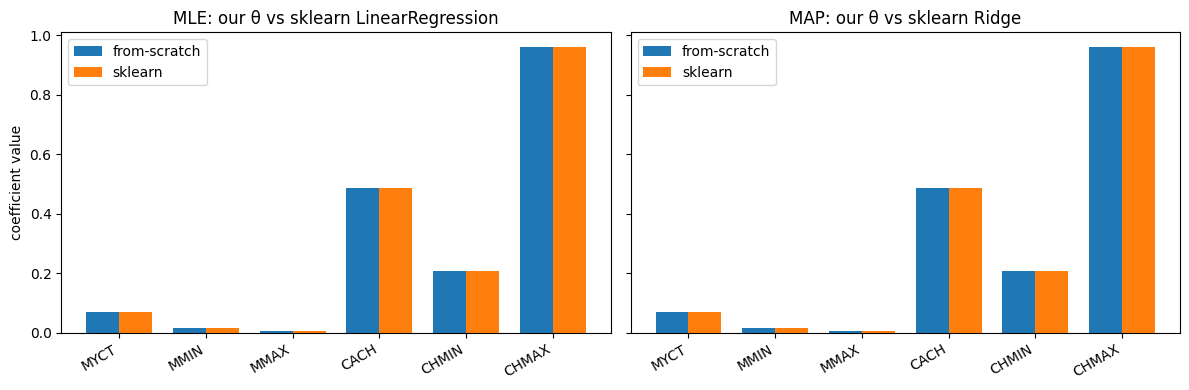

=== Part 2(b): θ and MSE comparison summary ===
Test MSE (ours MLE)    : 2499.8650
Test MSE (sklearn MLE) : 2499.8650
Test MSE (ours MAP)    : 2500.6071
Test MSE (sklearn MAP) : 2500.6071

Max |θ_MLE - θ_sklearn| (excluding bias): 1.277e-15
Max |θ_MAP - θ_ridge|  (excluding bias): 7.189e-15


In [95]:
# Part 2(b): Visual θ comparison (from-scratch vs scikit-learn), excluding bias

feat_names = coef_names[1:]
theta_mle_ours = theta_mle_reg[1:]
theta_mle_sk = theta_sklearn_mle[1:]
theta_map_ours = theta_map_reg[1:]
theta_map_sk = theta_sklearn_map[1:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x = np.arange(len(feat_names))
width = 0.38

# MLE comparison
axes[0].bar(x - width / 2, theta_mle_ours, width, label="from-scratch")
axes[0].bar(x + width / 2, theta_mle_sk, width, label="sklearn")
axes[0].axhline(0.0, color="black", linewidth=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(feat_names, rotation=30, ha="right")
axes[0].set_title("MLE: our θ vs sklearn LinearRegression")
axes[0].set_ylabel("coefficient value")
axes[0].legend()

# MAP (ridge) comparison
axes[1].bar(x - width / 2, theta_map_ours, width, label="from-scratch")
axes[1].bar(x + width / 2, theta_map_sk, width, label="sklearn")
axes[1].axhline(0.0, color="black", linewidth=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(feat_names, rotation=30, ha="right")
axes[1].set_title("MAP: our θ vs sklearn Ridge")
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== Part 2(b): θ and MSE comparison summary ===")
print(f"Test MSE (ours MLE)    : {mse_mle:.4f}")
print(f"Test MSE (sklearn MLE) : {mse_sklearn_mle:.4f}")
print(f"Test MSE (ours MAP)    : {mse_map:.4f}")
print(f"Test MSE (sklearn MAP) : {mse_sklearn_map:.4f}")
print("")
print(f"Max |θ_MLE - θ_sklearn| (excluding bias): {float(np.max(np.abs(theta_mle_ours - theta_mle_sk))):.3e}")
print(f"Max |θ_MAP - θ_ridge|  (excluding bias): {float(np.max(np.abs(theta_map_ours - theta_map_sk))):.3e}")

#### Evaluation of part 2b: θ comparison vs scikit-learn (excluding bias)
#### Validation of personal implementation by comparing with Scikit-learn's
From resulting test MSE, 
```
Test MSE (MLE/OLS): 2499.8650
Test MSE (MAP/Ridge): 2500.6071

Test MSE (sklearn LinearRegression): 2499.8650
Test MSE (sklearn Ridge, alpha=λ):   2500.6071
```

Additionally, we compare the feature weights but excluding the bias/intercept between:
- our MLE/OLS vs scikit-learn `LinearRegression`, and
- our MAP/ridge vs scikit-learn `Ridge(alpha=\lambda)`.

as shown from the plots above. 

We see that both personal implementation and sklearn library's output have the same MSE and final weight vectors (shown by the individual coefficients) up to floating-point precision. This is likely due to the fact that we are solving the same mathematical problem, using similar parameters and same train/test split. Matching sklearn is a form of validation and discrepancies would have indicated a setup mismatch rather than ‘expected difference’.

The magnitudes of the individual coefficients are plotted above for both the MLE and MAP models. The plotted feature weights (excluding bias) overlap almost exactly, and the max absolute coefficient difference is on the order of floating-point roundoff.


#### Qualitative analysis: coefficient magnitudes and shrinkage (MLE vs MAP)
The coefficient-magnitude plot compares $|\theta_j|$ across features for MLE vs MAP (bias excluded for readability). MAP (ridge) generally produces smaller-magnitude weights because of the Gaussian prior $\theta\sim\mathcal{N}(0,\lambda^{-1}I)$. Maximizing the posterior is equivalent to minimizing a regularized objective:
$$\theta_{\mathrm{MAP}} = \arg\min_\theta\;\lVert y-X\theta\rVert_2^2 + \lambda\lVert\theta\rVert_2^2.$$
The extra term $\lambda\lVert\theta\rVert_2^2$ explicitly penalizes large coefficients, so the optimizer prefers solutions with smaller $\lVert\theta\rVert_2$ unless increasing $\lVert\theta\rVert_2$ gives a strong improvement in data-fit. This is the shrinkage effect, such that MAP weights are generally smaller in magnitude than the MLE weights.

**Similarity in MLE and MAP weights**  
Despite the theory, our results show that the weights have very little difference. A possible reason is that $\lambda=0.11$ is relatively small in this dataset/feature scaling. Ridge differs from OLS by replacing $X^\top X$ with $X^\top X+\lambda I$. When $\lambda$ is tiny compared to the typical scale of $X^\top X$ (which can be very large because features like `MMIN`/`MMAX` have values in the tens of thousands), adding $0.11I$ barely changes the linear system. Therefore $\theta_{\mathrm{MAP}}\approx \theta_{\mathrm{MLE}}$ and the test MSEs are nearly identical. In general, if we used a larger $\lambda$ (stronger prior), had fewer training samples, or had noisier data, the shrinkage and MSE differences would be more noticeable.

**How does shrinkage act as regularization (and thus which achieves better generalization)?**  
Shrinking weights reduces the model’s variance (sensitivity to noise / sampling) at the cost of increased bias (bias–variance trade-off). This is especially helpful when features are correlated or poorly scaled (as shown in Part 2(a)), where OLS can overreact along poorly determined directions and produce large-magnitude coefficients. Ridge/MAP dampens those directions, which typically reduces overfitting risk on unseen hardware data.

Thus, shrinkage (such as via MAP and Ridge) reduces overfitting of training data, so that it generalises better for unseen hardware data. But this reduction in variance will cause an increase in bias.

**How the prior distribution mitigates overfitting**  
From a Bayesian view, the prior $p(\theta)=\mathcal{N}(0,\lambda^{-1}I)$ assigns higher probability to small weights and low probability to large weights. The posterior combines data-fit and prior via $p(\theta\mid X,y)\propto p(y\mid X,\theta)p(\theta)$, so when the data are noisy, limited, or ill-conditioned, the prior prevents the estimate from taking extreme coefficient values that would “chase noise” on the training set. This reduces model complexity / variance and improves generalization on unseen hardware data (at the cost of increased bias, especially when $\lambda$ is larger).

### AI Usage Declaration
I have used copilot to help me with Latex notations and checking through my codes for any obvious errors, especially for plotting of data.